### Part II: Self-Play with One Model

#### Name: Tracy Chen, Hayley Shin (Group No: 7)

#### II.1 Game definition

Phase A: generate answers

1. For each row (letter, category) and each round index, have the player output one answer. Write a prompt that wraps around the category and letter from scattergories_questions.csv, and set the temperature informed by your experiences above. Run both instances of the model (player 1 and player 2) with the same prompt and same temperature (optional: explore varying temperature here as well).
2. Write the answers to a CSV file in the required format.
3. Keep this generation step independent from judging.

Phase B: judge and score

1. Run judge.py on one or more answer files. Reminder that will require your OpenAI API key.
2. The judge script will:
    - call a GPT judge for validity (yes/no)
    - normalize answers
    - compute points across submitted player files
    - output score CSV
3. Audit quality: randomly sample at least 50 judged examples and manually verify them; report estimated judge error rate.

In [107]:
# import library
import math
import json
import random
import subprocess
import sys
from collections import Counter, defaultdict
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

##### Self-play Experiment 1
- model: qwen2.5:7b
- rounds: 20
- temperature: 0.8
- top-k: 40
- prompt-file: Part2/scattergories_selfplay.txt

In [108]:
# load data and results
judged_exp1 = pd.read_csv("outputs/judged_rows.csv")
scores_exp1 = pd.read_csv("outputs/scores.csv")
scores_exp1

,player_id,source_file,total_answers,valid_answers,valid_rate,points,avg_points_per_answer,collisions,collision_rate,distinct_valid_answers,judge_api_calls,judge_cache_hits
0,answers_player1,Part2/outputs/answers_player1.csv,1280,916,0.715625,363,0.283594,553,0.432031,140,395,2165
1,answers_player2,Part2/outputs/answers_player2.csv,1280,909,0.710156,356,0.278125,553,0.432031,137,395,2165


In [109]:
# audit quality
#   randomly sample at least 50 judged examples and manually verify them
#   report estimated judge error rate

# randomly sample at least 50 judged examples (randomly sample 50 round_key)
audit_n = 50
audit_seed = 260302
sampled_keys = (judged_exp1["round_key"].drop_duplicates().sample(n=audit_n, random_state=audit_seed))
audit_sample = (judged_exp1[judged_exp1["round_key"].isin(sampled_keys)].sort_values(["round_key", "player_id"]).reset_index(drop=True))
audit_sample.index += 1

# print results
print(f"Sample Validity Rate  : {audit_sample['valid'].mean():.3f}")
print(f"Sample Avgerage Score : {audit_sample['score'].mean():.3f}")

# save audit_sample to csv
audit_sample.to_csv("outputs/audit_sample.csv", index=True)

Sample Validity Rate  : 0.660
Sample Avgerage Score : 0.280


In [110]:
# check audit sample
audit_sample

,source_file,player_id,question_id,letter,category,round_idx,answer_raw,answer_norm,valid,collision,score,round_key
1,Part2/outputs/answers_player1.csv,answers_player1,Q001,A,Animals,15,albatross,albatross,1,1,0,Q001::15
2,Part2/outputs/answers_player2.csv,answers_player2,Q001,A,Animals,15,albatross,albatross,1,1,0,Q001::15
3,Part2/outputs/answers_player1.csv,answers_player1,Q004,B,Things that are red,3,banana,banana,0,0,0,Q004::3
4,Part2/outputs/answers_player2.csv,answers_player2,Q004,B,Things that are red,3,banana,banana,0,0,0,Q004::3
5,Part2/outputs/answers_player1.csv,answers_player1,Q006,C,Board games,16,chess,chess,1,1,0,Q006::16
...,...,...,...,...,...,...,...,...,...,...,...,...
96,Part2/outputs/answers_player2.csv,answers_player2,Q062,J,Things in a refrigerator,6,juice,juice,1,1,0,Q062::6
97,Part2/outputs/answers_player1.csv,answers_player1,Q064,L,Things in a library,14,library card,library card,0,0,0,Q064::14
98,Part2/outputs/answers_player2.csv,answers_player2,Q064,L,Things in a library,14,library card,library card,0,0,0,Q064::14
99,Part2/outputs/answers_player1.csv,answers_player1,Q064,L,Things in a library,5,library card,library card,0,0,0,Q064::5


In [111]:
# manually verify audit_sample
valid_manual = [1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
audit_sample['valid_manual'] = valid_manual
# compute collision_manual and score_manual
audit_sample["collision_manual"] = 0
audit_sample["score_manual"] = 0
grouped = audit_sample.groupby(["question_id", "round_idx"])
for (q_id, r_id), group in grouped:
    valid_answers = group.loc[group["valid_manual"] == 1, "answer_norm"]
    counts = Counter(valid_answers)
    for idx in group.index:
        valid = audit_sample.loc[idx, "valid_manual"] == 1
        ans = audit_sample.loc[idx, "answer_norm"]
        collision = valid and ans != "" and counts.get(ans, 0) > 1   # same logic with judge.py
        score = int(valid and not collision)
        audit_sample.loc[idx, "collision_manual"] = int(collision)
        audit_sample.loc[idx, "score_manual"] = score

# save audit_sample to csv
audit_sample.to_csv("outputs/audit_sample.csv", index=True)
audit_sample

,source_file,player_id,question_id,letter,category,round_idx,answer_raw,answer_norm,valid,collision,score,round_key,valid_manual,collision_manual,score_manual
1,Part2/outputs/answers_player1.csv,answers_player1,Q001,A,Animals,15,albatross,albatross,1,1,0,Q001::15,1,1,0
2,Part2/outputs/answers_player2.csv,answers_player2,Q001,A,Animals,15,albatross,albatross,1,1,0,Q001::15,1,1,0
3,Part2/outputs/answers_player1.csv,answers_player1,Q004,B,Things that are red,3,banana,banana,0,0,0,Q004::3,0,0,0
4,Part2/outputs/answers_player2.csv,answers_player2,Q004,B,Things that are red,3,banana,banana,0,0,0,Q004::3,0,0,0
5,Part2/outputs/answers_player1.csv,answers_player1,Q006,C,Board games,16,chess,chess,1,1,0,Q006::16,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,Part2/outputs/answers_player2.csv,answers_player2,Q062,J,Things in a refrigerator,6,juice,juice,1,1,0,Q062::6,1,1,0
97,Part2/outputs/answers_player1.csv,answers_player1,Q064,L,Things in a library,14,library card,library card,0,0,0,Q064::14,1,1,0
98,Part2/outputs/answers_player2.csv,answers_player2,Q064,L,Things in a library,14,library card,library card,0,0,0,Q064::14,1,1,0
99,Part2/outputs/answers_player1.csv,answers_player1,Q064,L,Things in a library,5,library card,library card,0,0,0,Q064::5,1,1,0


In [112]:
# calculate error rate
# valid error
audit_sample["valid_error"] = audit_sample["valid"] != audit_sample["valid_manual"]
# collision error
audit_sample["collision_error"] = audit_sample["collision"] != audit_sample["collision_manual"]
# score error
audit_sample["score_error"] = audit_sample["score"] != audit_sample["score_manual"]

# print result
print("Valid Error Rate :", audit_sample["valid_error"].mean())
print("Collision Error Rate :", audit_sample["collision_error"].mean())
print("Score Error Rate :", audit_sample["score_error"].mean())

Valid Error Rate : 0.18
Collision Error Rate : 0.08
Score Error Rate : 0.1


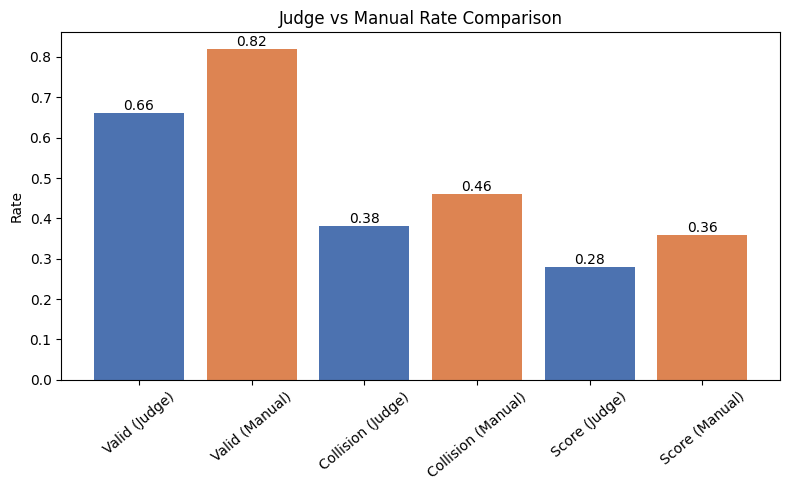

In [113]:
# create plot for judge vs manual
# calculate valid, collision, score rate for judge and manual
valid_j = audit_sample["valid"].mean()
valid_m = audit_sample["valid_manual"].mean()
collision_j = audit_sample["collision"].mean()
collision_m = audit_sample["collision_manual"].mean()
score_j = audit_sample["score"].mean()
score_m = audit_sample["score_manual"].mean()
# labels
labels = ["Valid (Judge)", "Valid (Manual)", "Collision (Judge)", "Collision (Manual)", "Score (Judge)", "Score (Manual)"]
values = [valid_j, valid_m, collision_j, collision_m, score_j, score_m]
colors = ["#4C72B0", "#DD8452", "#4C72B0", "#DD8452", "#4C72B0", "#DD8452"]   # judge = blue, manual = orange
plt.figure(figsize=(8,5))
bars = plt.bar(labels, values, color=colors)
plt.ylabel("Rate")
plt.title("Judge vs Manual Rate Comparison")
plt.xticks(rotation=40)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )
plt.tight_layout()
plt.show()

#### II.2 Self-play experiments
1. Once you have generation and judging figured out, run repeated rounds for each question (enough rounds for stable estimates (of the expected score) and store generated answers.
2. Run judge.py on your generated files to compute game outcomes from self-play.
3. Measure per-question and overall outcomes:
    - Validity rate
    - Average score per player
4. Revisit prompt/temperature choices and see whether you can improve the self-play score.

##### Overall Validity Rate, Collision Rate, and Avg Score

In [31]:
# add collisions / valid_answers columns to scores
scores_exp1["collision_rate_of_valid"] = scores_exp1["collisions"] / scores_exp1["valid_answers"]
scores_exp1

,player_id,source_file,total_answers,valid_answers,valid_rate,points,avg_points_per_answer,collisions,collision_rate,distinct_valid_answers,judge_api_calls,judge_cache_hits,collision_rate_of_valid
0,answers_player1,Part2/outputs/answers_player1.csv,1280,916,0.715625,363,0.283594,553,0.432031,140,395,2165,0.603712
1,answers_player2,Part2/outputs/answers_player2.csv,1280,909,0.710156,356,0.278125,553,0.432031,137,395,2165,0.608361


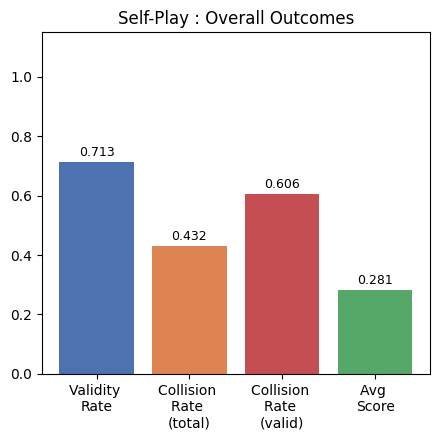

In [69]:
# overall
overall_exp1 = scores_exp1[["valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]].mean()
values = ["valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]
labels  = ["Validity \nRate", "Collision \nRate \n(total)", "Collision \nRate \n(valid)", "Avg \nScore"]
colors  = ["#4C72B0", "#DD8452", "#C44E52", "#55A868"]
vals    = [overall_exp1[a] for a in values]

fig, ax = plt.subplots(figsize=(4.5, 4.5))
bars = ax.bar(labels, vals, color=colors)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01, f"{v:.3f}",
            ha="center", va="bottom", fontsize=9)

ax.set_ylim(0, 1.15)
ax.set_title("Self-Play : Overall Outcomes")
plt.tight_layout()
plt.show()

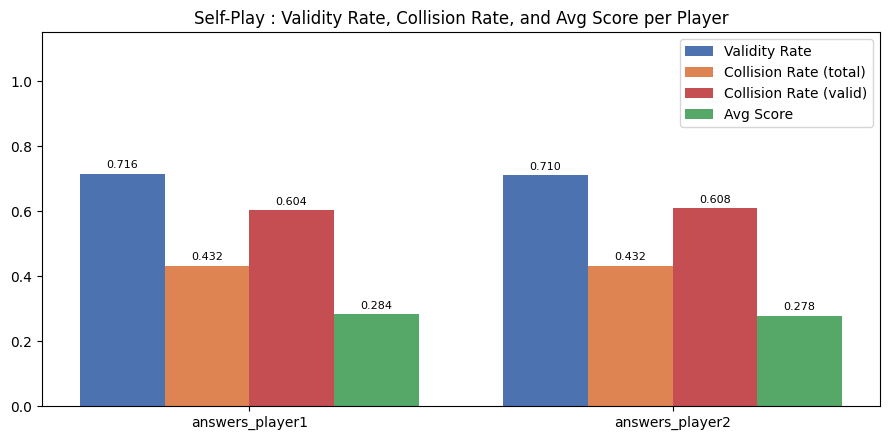

In [ ]:
# overall (per player)
players = scores_exp1["player_id"].tolist()
values = ["valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]
labels  = ["Validity Rate", "Collision Rate (total)", "Collision Rate (valid)", "Avg Score"]
colors  = ["#4C72B0", "#DD8452", "#C44E52", "#55A868"]
x = np.arange(len(players))
w = 0.2

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, (a, lbl, col) in enumerate(zip(values, labels, colors)):
    vals = scores_exp1[a].tolist()
    bars = ax.bar(x + i * w, vals, w, label=lbl, color=col)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01, f"{v:.3f}",
                ha="center", va="bottom", fontsize=8)
ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(players, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_title("Self-Play : Validity Rate, Collision Rate, and Avg Score per Player")
ax.legend()
plt.tight_layout()
plt.show()

##### Per-Question Validity Rate, Collision Rate, and Avg Score

In [ ]:
per_question = (judged_exp1.groupby(["question_id", "letter", "category"]).apply(lambda g: pd.Series({"validity_rate" : g["valid"].mean(),
                                                                                                      "avg_score" : g["score"].mean(),
                                                                                                      "collision_rate_of_total" : g["collision"].mean(),
                                                                                                      "collision_rate_of_valid" : (g["collision"].sum() / g["valid"].sum() if g["valid"].sum() > 0 else float("nan")),
                                                                                                    }), include_groups=False).reset_index())
per_question["q_label"] = per_question["category"].str[:50] + "/" + per_question["letter"]
per_question

,question_id,letter,category,validity_rate,avg_score,collision_rate_of_total,collision_rate_of_valid,q_label
0,Q001,A,Animals,1.000,0.850,0.15,0.150000,Animals/A
1,Q002,A,Jobs,1.000,0.000,1.00,1.000000,Jobs/A
2,Q003,B,Fruits,1.000,0.150,0.85,0.850000,Fruits/B
3,Q004,B,Things that are red,0.025,0.025,0.00,0.000000,Things that are red/B
4,Q005,C,Countries,1.000,0.000,1.00,1.000000,Countries/C
...,...,...,...,...,...,...,...,...
59,Q060,H,Countries,0.700,0.400,0.30,0.428571,Countries/H
60,Q061,I,Musical artists,0.075,0.075,0.00,0.000000,Musical artists/I
61,Q062,J,Things in a refrigerator,1.000,0.150,0.85,0.850000,Things in a refrigerator/J
62,Q063,K,Cities,0.975,0.825,0.15,0.153846,Cities/K


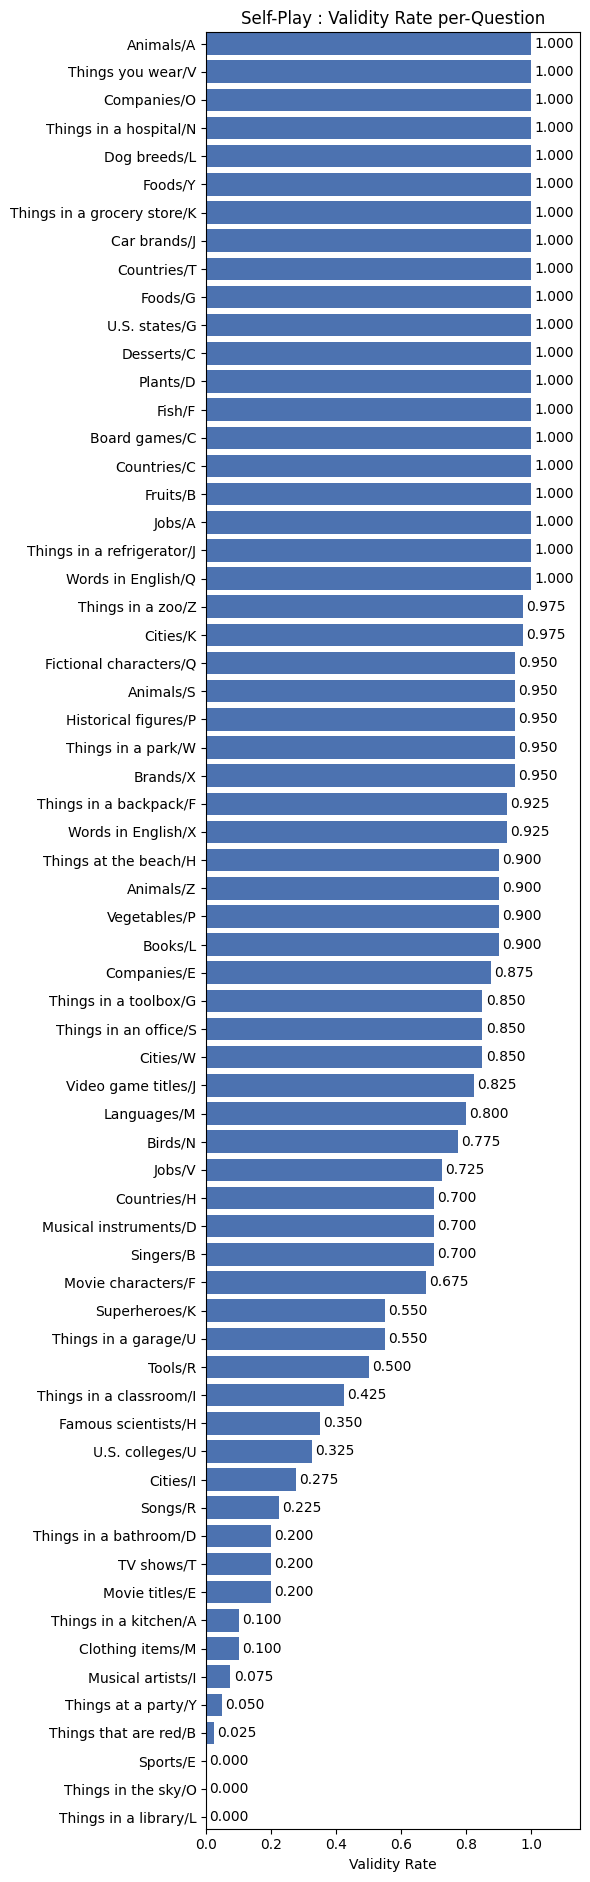

In [89]:
# per-question results
per_question_sort = per_question.sort_values("validity_rate").reset_index(drop=True)
labels = per_question_sort["q_label"].tolist()

# validity rate
fig, ax = plt.subplots(figsize=(6, max(5, len(labels) * 0.28 + 1)))
bars = ax.barh(labels, per_question_sort["validity_rate"], color="#4C72B0")
for bar, v in zip(bars, per_question_sort["validity_rate"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{v:.3f}", va="center", fontsize=10)
ax.set_xlabel("Validity Rate")
ax.set_title("Self-Play : Validity Rate per-Question")
ax.set_xlim(0, 1.15)
ax.margins(y=0)
plt.tight_layout()
plt.show()

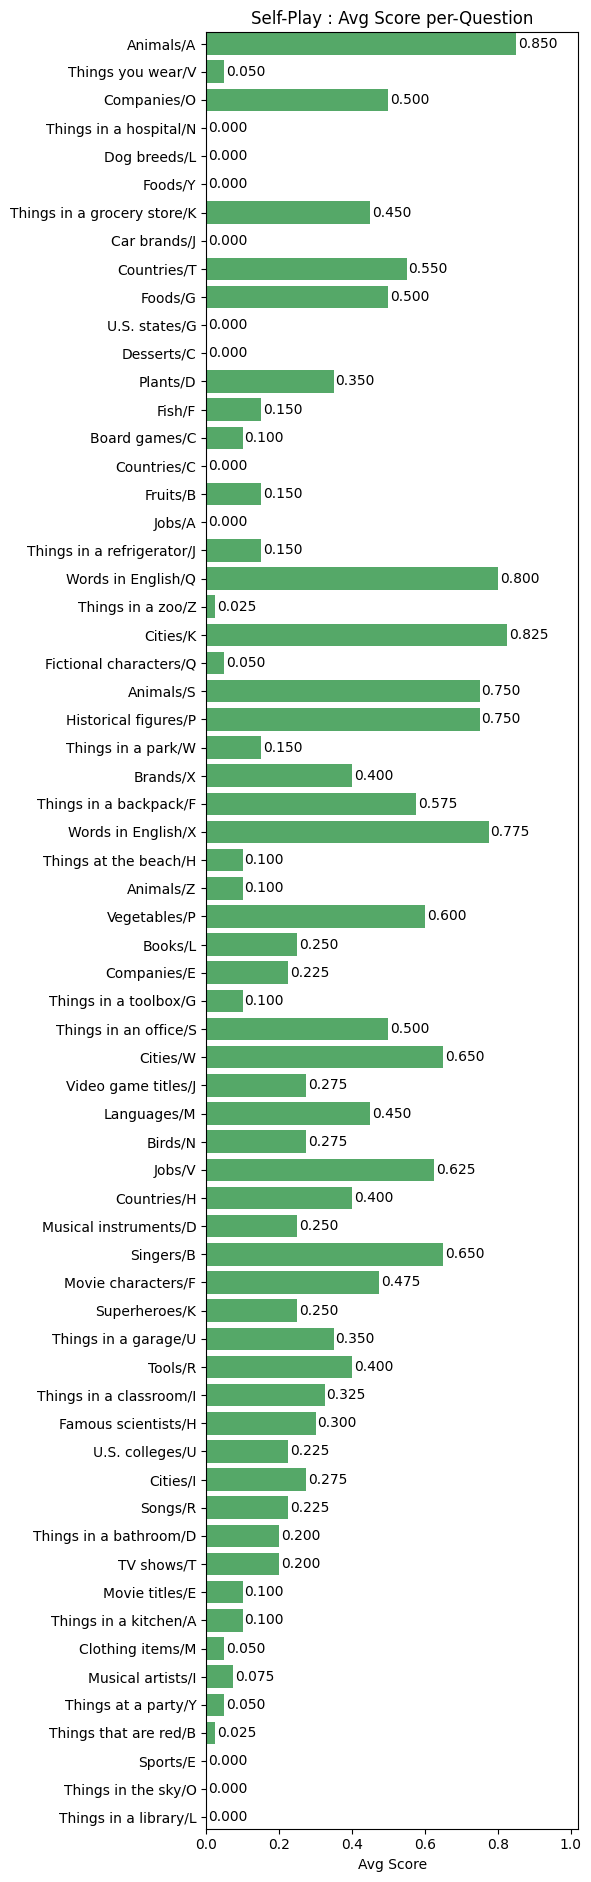

In [90]:
# average score
fig, ax = plt.subplots(figsize=(6, max(5, len(labels) * 0.28 + 1)))
bars = ax.barh(labels, per_question_sort["avg_score"], color="#55A868")
for bar, v in zip(bars, per_question_sort["avg_score"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{v:.3f}", va="center", fontsize=10)
ax.set_xlabel("Avg Score")
ax.set_title("Self-Play : Avg Score per-Question")
ax.set_xlim(0, max(per_question_sort["avg_score"].max(), 0.5) * 1.2)
ax.margins(y=0)
plt.tight_layout()
plt.show()

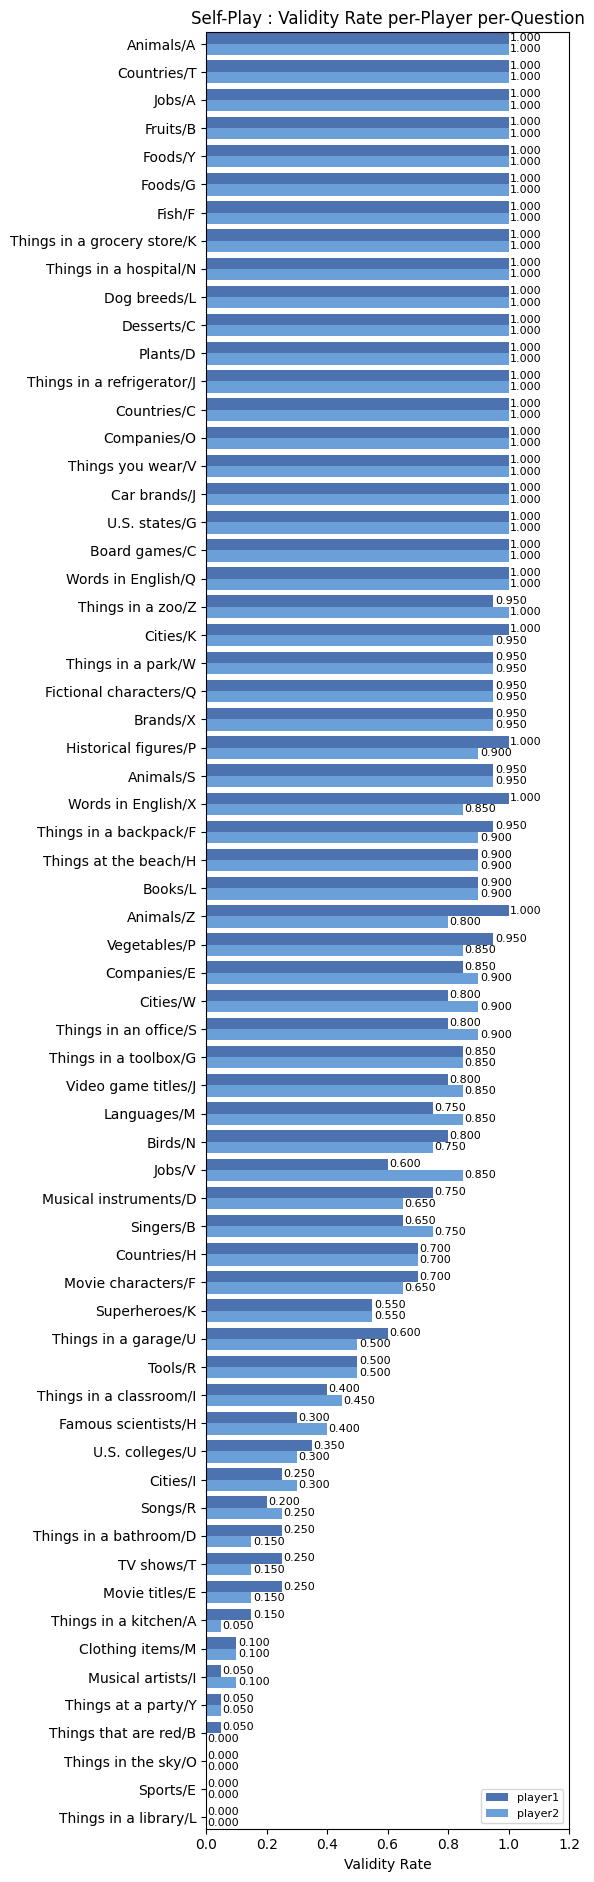

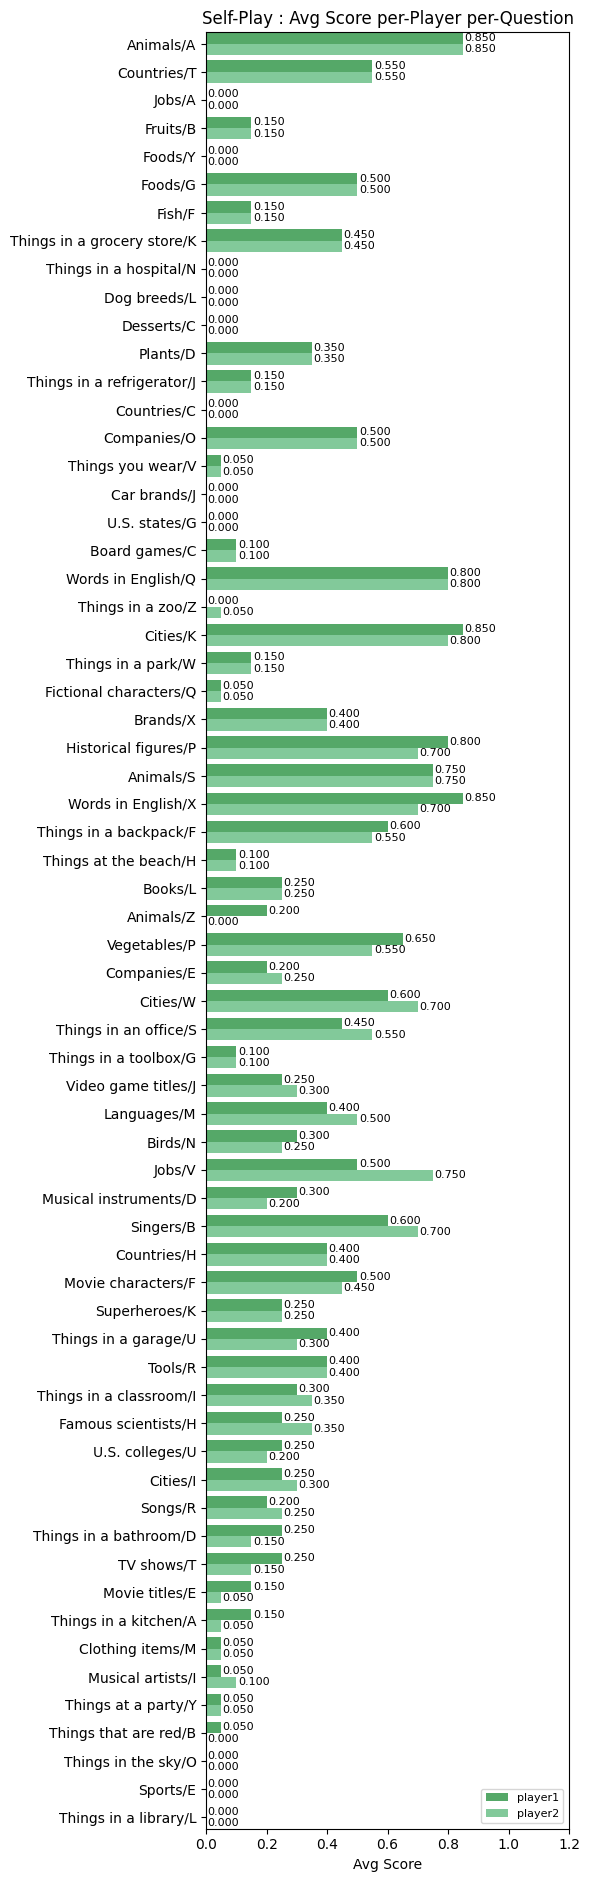

In [ ]:
# per-question per-player
players = sorted(judged_exp1["player_id"].unique())
judged_exp1["q_label"] = judged_exp1["category"].str[:50] + "/" + judged_exp1["letter"]
per_question_player = (judged_exp1.groupby(["q_label", "player_id"]).agg(validity_rate=("valid", "mean"), avg_score=("score", "mean")).reset_index())
order = (per_question_player.groupby("q_label")["validity_rate"].mean().sort_values().index.tolist())
per_question_player["q_label"] = pd.Categorical(per_question_player["q_label"], categories=order, ordered=True)
per_question_player = per_question_player.sort_values("q_label")

n_q = len(order)
n_p = len(players)
y = np.arange(n_q)
bar_h = 0.8 / n_p
for values, color_list, xlabel, title in [("validity_rate", ["#4C72B0", "#6A9FD8"], "Validity Rate", "Self-Play : Validity Rate per-Player per-Question"),
                                          ("avg_score", ["#55A868", "#82C99A"], "Avg Score", "Self-Play : Avg Score per-Player per-Question"),]:
    fig, ax = plt.subplots(figsize=(6, max(5, n_q * 0.28 + 1)))
    for i, (player, color) in enumerate(zip(players, color_list)):
        vals = per_question_player[per_question_player["player_id"] == player][values].tolist()
        bars = ax.barh(y - i * bar_h + bar_h / 2, vals, bar_h,
                       label=player.replace("answers_", ""), color=color)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                    f"{v:.3f}", va="center", fontsize=8)
    ax.set_yticks(y)
    ax.set_yticklabels(order, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.set_xlim(0, 1.2)
    ax.legend(fontsize=8)
    ax.margins(y=0)
    plt.tight_layout()
    plt.show()

##### Self-play Experiment 2 (change temperature choices)
- model: qwen2.5:7b
- rounds: 20
- temperature: 0.4, 0.8 (baseline), 1.5, and 5.0
- top-k: 40
- prompt-file: Part2/scattergories_selfplay.txt

*Player 1 and Player 2 achieved very similar scores under identical settings, as expected in self-play. We therefore check overall outcomes.*

In [ ]:
# load data
scores_base = pd.read_csv("outputs/scores.csv")
scores_t04 = pd.read_csv("outputs/scores_T0.4.csv")
scores_t15 = pd.read_csv("outputs/scores_T1.5.csv")
scores_t50 = pd.read_csv("outputs/scores_T5.0.csv")

# add column
for df in [scores_base, scores_t04, scores_t15, scores_t50]:
    df["collision_rate_of_valid"] = df["collisions"] / df["valid_answers"]

# df for comparison
rows = []
for label, df in [("T=0.4", scores_t04), ("T=0.8", scores_base), ("T=1.5", scores_t15), ("T=5.0", scores_t50),]:
    rows.append({"temp": label,
                 "valid_rate": df["valid_rate"].mean(),
                 "collision_rate": df["collision_rate"].mean(),
                 "collision_rate_of_valid": df["collision_rate_of_valid"].mean(),
                 "avg_points_per_answer": df["avg_points_per_answer"].mean(),})
compare_temp = pd.DataFrame(rows)
compare_temp

,temp,valid_rate,collision_rate,collision_rate_of_valid,avg_points_per_answer
0,T=0.4,0.752344,0.562500,0.747667,0.189844
1,T=0.8,0.712891,0.432031,0.606036,0.280859
2,T=1.5,0.695312,0.341406,0.491017,0.353906
3,T=5.0,0.641797,0.271875,0.423642,0.369922


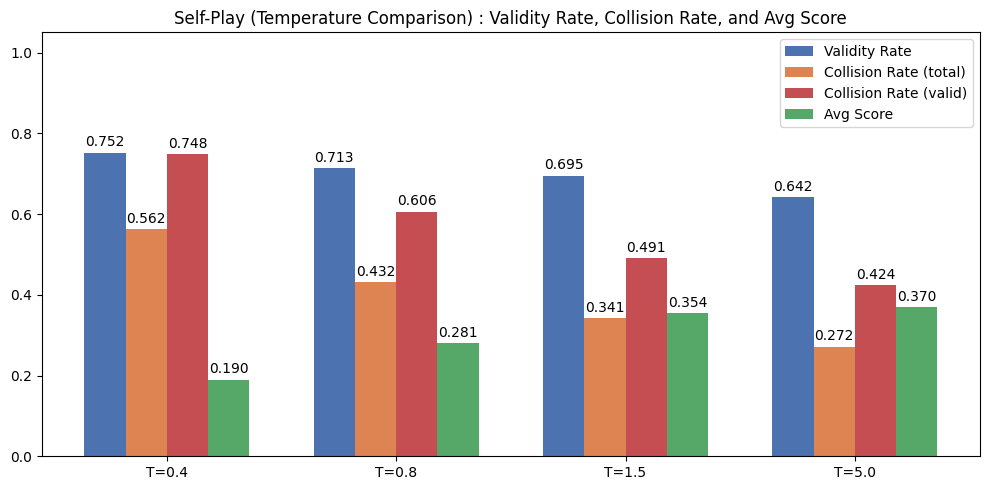

In [ ]:
# plot for self-play temperature comparison
values = ["valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]
labels = ["Validity Rate", "Collision Rate (total)", "Collision Rate (valid)", "Avg Score"]
colors = ["#4C72B0", "#DD8452", "#C44E52", "#55A868"]

temps = compare_temp["temp"].tolist()
x = np.arange(len(temps))
w = 0.18
fig, ax = plt.subplots(figsize=(10, 5))
for i, (a, lbl, col) in enumerate(zip(values, labels, colors)):
    bars = ax.bar(x + i * w, compare_temp[a], w, label=lbl, color=col)
    for bar, v in zip(bars, compare_temp[a]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008, f"{v:.3f}",
                ha="center", va="bottom", fontsize=10)
ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(temps, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title("Self-Play (Temperature Comparison) : Validity Rate, Collision Rate, and Avg Score")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

##### Self-play Experiment 3 (change prompt choices)
- model: qwen2.5:7b
- rounds: 20
- temperature: 0.8
- top-k: 40
- prompt-file: Part2/scattergories_selfplay.txt and Part2/scattergories_selfplay2.txt

*Player 1 and Player 2 achieved very similar scores under identical settings, as expected in self-play. We therefore check overall outcomes.*

In [104]:
# load data
scores_base = pd.read_csv("outputs/scores.csv")
scores_prompt2 = pd.read_csv("outputs/scores_prompt2.csv")

# add column
for df in [scores_base, scores_prompt2]:
    df["collision_rate_of_valid"] = df["collisions"] / df["valid_answers"]

# df for comparison
rows = []
for label, df in [("prompt1", scores_base), ("prompt2", scores_prompt2),]:
    rows.append({"prompt": label,
                 "valid_rate": df["valid_rate"].mean(),
                 "collision_rate": df["collision_rate"].mean(),
                 "collision_rate_of_valid": df["collision_rate_of_valid"].mean(),
                 "avg_points_per_answer": df["avg_points_per_answer"].mean(),})
compare_prompt = pd.DataFrame(rows)
compare_prompt

,prompt,valid_rate,collision_rate,collision_rate_of_valid,avg_points_per_answer
0,prompt1,0.712891,0.432031,0.606036,0.280859
1,prompt2,0.698047,0.371094,0.531625,0.326953


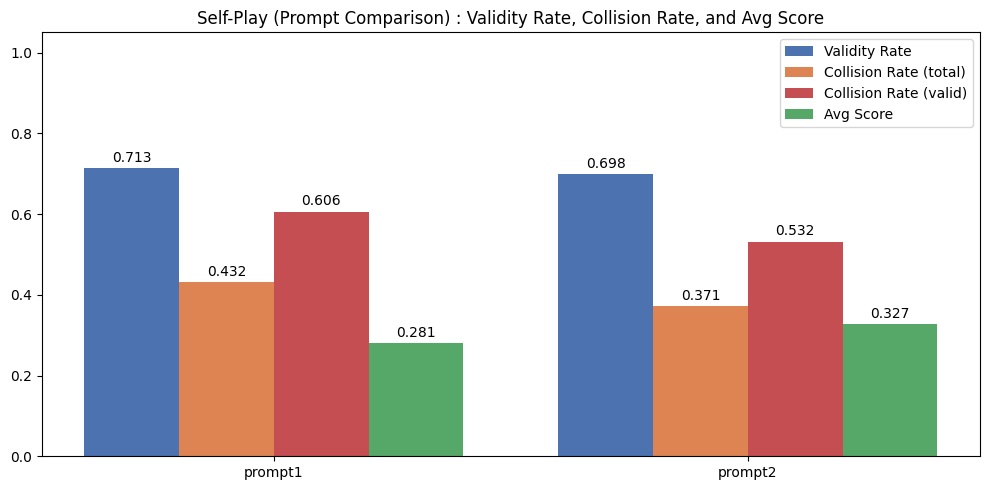

In [ ]:
# plot for self-play temperature comparison
values = ["valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]
labels = ["Validity Rate", "Collision Rate (total)", "Collision Rate (valid)", "Avg Score"]
colors = ["#4C72B0", "#DD8452", "#C44E52", "#55A868"]

prompts = compare_prompt["prompt"].tolist()
x = np.arange(len(prompts))
w = 0.2
fig, ax = plt.subplots(figsize=(10, 5))
for i, (a, lbl, col) in enumerate(zip(values, labels, colors)):
    bars = ax.bar(x + i * w, compare_prompt[a], w, label=lbl, color=col)
    for bar, v in zip(bars, compare_prompt[a]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008, f"{v:.3f}",
                ha="center", va="bottom", fontsize=10)
ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(prompts, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title("Self-Play (Prompt Comparison) : Validity Rate, Collision Rate, and Avg Score")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()